
### Load the data

In [47]:
import pandas as pd 
import matplotlib.pyplot as plt

prices = pd.read_parquet("../data/processed/prices.parquet")
weather = pd.read_parquet("../data/processed/weather.parquet")

print(prices.shape)
print(weather.shape)

(236636, 7)
(122404, 6)


In [48]:
prices.head()

,sek_per_kwh,eur_per_kwh,exr,time_start,time_end,zone,resolution
0,0.37995,0.03491,10.883706,2022-11-01 00:00:00+01:00,2022-11-01 01:00:00+01:00,SE1,hourly
1,0.37995,0.03491,10.883706,2022-11-01 01:00:00+01:00,2022-11-01 02:00:00+01:00,SE1,hourly
2,0.38430,0.03531,10.883706,2022-11-01 02:00:00+01:00,2022-11-01 03:00:00+01:00,SE1,hourly
3,0.39301,0.03611,10.883706,2022-11-01 03:00:00+01:00,2022-11-01 04:00:00+01:00,SE1,hourly
4,0.41173,0.03783,10.883706,2022-11-01 04:00:00+01:00,2022-11-01 05:00:00+01:00,SE1,hourly


In [49]:
prices.dtypes

sek_per_kwh                             float64
eur_per_kwh                             float64
exr                                     float64
time_start     datetime64[us, Europe/Stockholm]
time_end       datetime64[us, Europe/Stockholm]
zone                                        str
resolution                                  str
dtype: object

In [50]:
prices.groupby("zone")["eur_per_kwh"].describe()

,count,mean,std,min,25%,50%,75%,max
zone,,,,,,,,
SE1,59159.0,0.037346,0.046922,-0.09459,0.00595,0.02167,0.05090,0.59000
SE2,59159.0,0.037581,0.047302,-0.06004,0.00499,0.02164,0.05318,0.59000
SE3,59159.0,0.060057,0.055564,-0.06004,0.02049,0.04927,0.08845,0.70752
SE4,59159.0,0.074236,0.062396,-0.06004,0.02593,0.06729,0.10775,0.79748


---

### Price distribution

SE4 is the most expensive zone at 0.074 EUR/kWh on average, twice SE1 at 0.037. SE1 and SE2 are almost identical, so the data really has three levels: north, middle, south. All four zones are right-skewed. In SE1 the mean is 72% above the median, meaning a small number of expensive hours pulls the average up. The skew is much weaker in SE4, where the mean is only 10% above the median. Northern prices are usually very low with occasional spikes, southern prices are more consistently high.

The tails are extreme. SE1's maximum of 0.59 is about 12 times its 75th percentile. In SE1 and SE2 the standard deviation is larger than the mean. All four zones have negative minimum prices, from -0.06 to -0.095. SE1 goes lowest, which fits a surplus zone with a lot of hydro and wind. All zones have exactly 59,159 rows, so coverage is symmetric.

---

### Price over time, all four zones

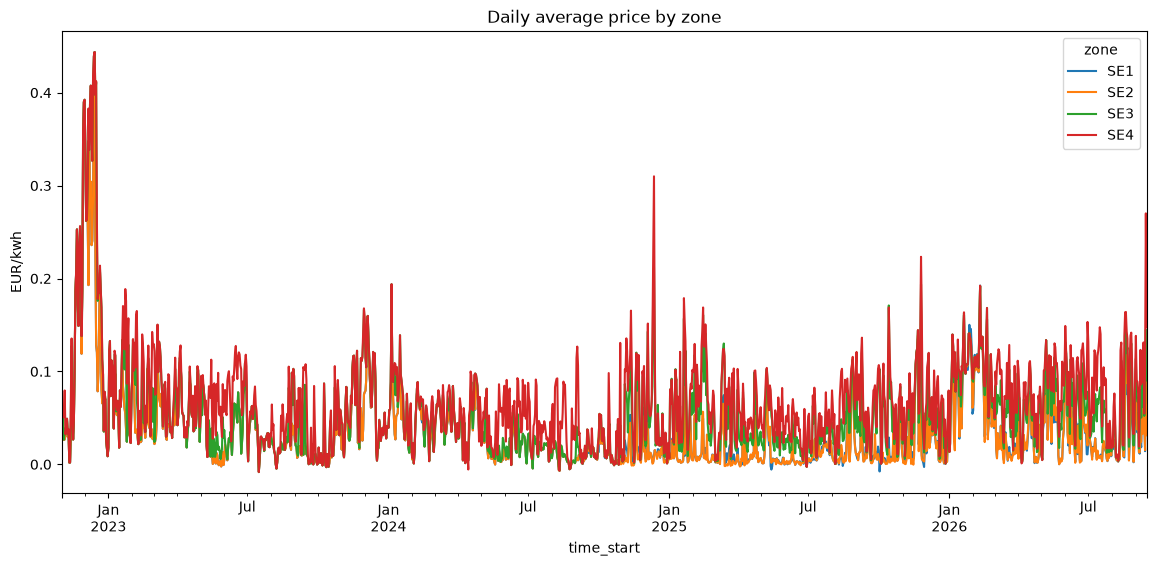

In [51]:
pivot = prices.pivot_table(index="time_start", columns="zone", values="eur_per_kwh")
daily = pivot.resample("D").mean()

daily.plot(figsize=(14, 6))
plt.ylabel("EUR/kwh")
plt.title("Daily average price by zone")
plt.show()

The first two months look nothing like the rest. In December 2022 SE4 reached 0.44 EUR/kWh, about 6 times its normal level. This was the energy crisis, and it is a different market regime from the rest of the data. 2024 was the calmest year. Spikes get more frequent again in 2025 and 2026.

---

### The spread

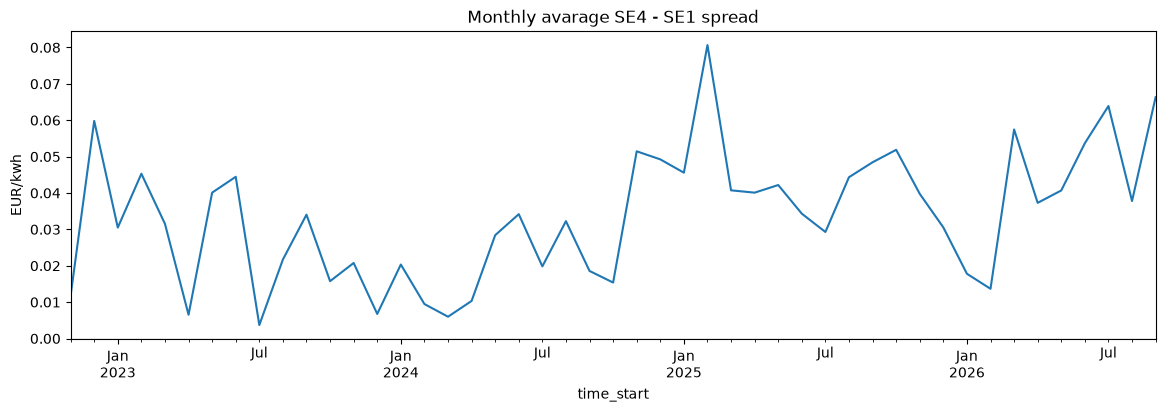

In [52]:
pivot["spread_SE4_SE1"] = pivot["SE4"] - pivot["SE1"]
pivot["spread_SE4_SE1"].resample("ME").mean().plot(figsize=(14, 4))

plt.ylabel("EUR/kwh")
plt.title("Monthly avarage SE4 - SE1 spread")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

The spread is positive in all 46 months. SE4 was never cheaper than SE1, not even on a monthly average. The bottleneck between north and south always works in the same direction. The spread is also growing. It was around 0.02 in 2023 and 2024, and is closer to 0.04-0.05 in 2025 and 2026. This matters because a model trained on early data will be tested on later data.

---

### Monthly seasonality

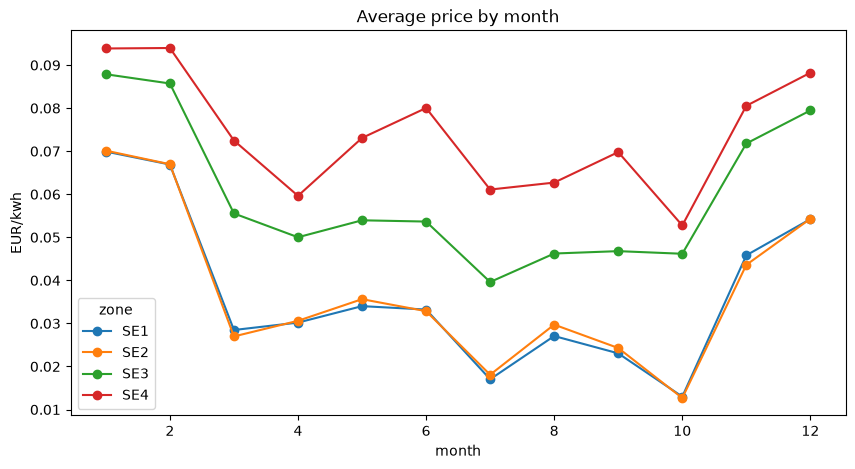

In [53]:
prices["month"] = prices["time_start"].dt.month
monthly = prices.groupby(["zone", "month"])["eur_per_kwh"].mean().unstack(0)
monthly.plot(figsize=(10,5), marker="o")

plt.ylabel("EUR/kwh")
plt.title("Average price by month")
plt.show()

Prices peak in winter and drop in summer, which follows heating demand. October is the cheapest month in every zone. Heating has not started yet, reservoirs are full after autumn rain, and it is usually windy. SE1 and SE2 follow each other almost exactly all year. The seasonal swing is much bigger in the north. SE1 goes from 0.013 to 0.070, about 5 times. SE4 only goes from 0.053 to 0.094, less than 2 times. There is a small bump in May and June, clearest in SE4.

---

### Hour of day

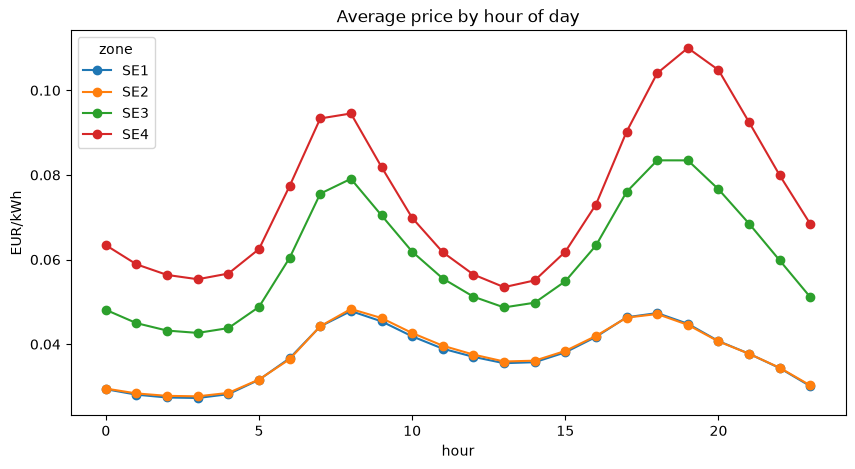

In [54]:
prices["hour"] = prices["time_start"].dt.hour
hourly = prices.groupby(["zone", "hour"])["eur_per_kwh"].mean().unstack(0)
hourly.plot(figsize=(10, 5), marker="o")

plt.ylabel("EUR/kWh")
plt.title("Average price by hour of day")
plt.show()

All four zones have the same shape: a morning peak around 07-08, an evening peak around 18-19, a low point at 03-04 and a smaller dip at 13-14. The midday dip is probably solar. The shape is the same everywhere but the size is not. SE4 swings from 0.055 to 0.110, a difference of 0.055. SE1 swings from 0.027 to 0.048, only 0.021.

---

### Day of the week

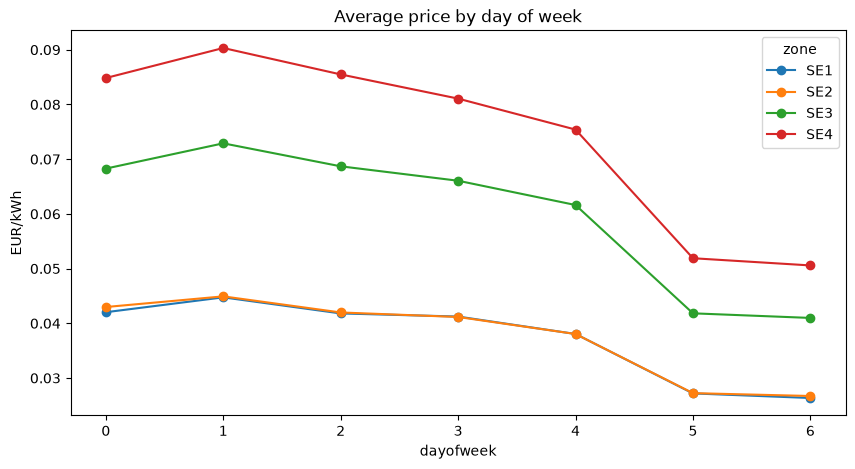

In [55]:
prices["dayofweek"] = prices["time_start"].dt.dayofweek
hourly = prices.groupby(["zone", "dayofweek"])["eur_per_kwh"].mean().unstack(0)
hourly.plot(figsize=(10, 5), marker="o")

plt.ylabel("EUR/kWh")
plt.title("Average price by day of week")
plt.show()

Weekends are much cheaper. From Friday to Saturday SE3 drops from 0.062 to 0.042, about a third, which fits industry shutting down. Tuesday is the most expensive day in every zone, not Monday. Saturday and Sunday are almost the same. An is_weekend feature should be useful, but day of week is worth keeping too since Tuesday and Friday behave differently.

---

### Hour and season

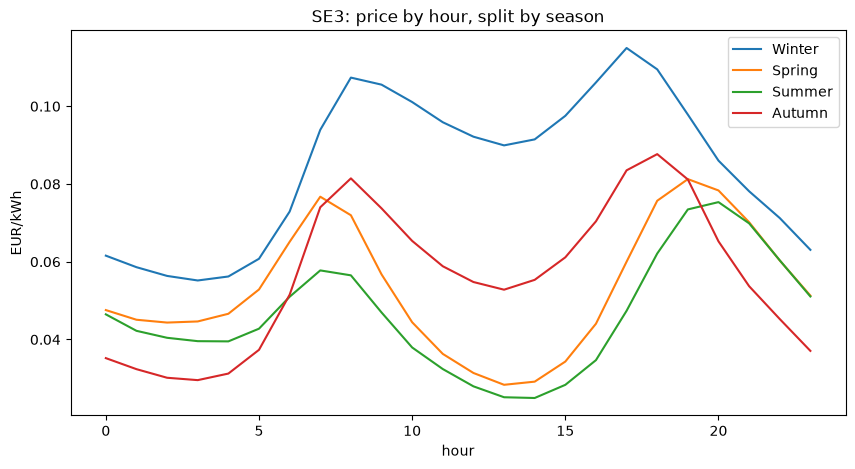

In [56]:
prices["season"] = prices["time_start"].dt.month % 12 // 3
season_names = {0: "Winter", 1: "Spring", 2: "Summer", 3: "Autumn"}

se3 = prices[prices["zone"] == "SE3"]
shape = se3.groupby(["season", "hour"])["eur_per_kwh"].mean().unstack(0)
shape.columns = [season_names[c] for c in shape.columns]

shape.plot(figsize=(10, 5))
plt.ylabel("EUR/kWh")
plt.title("SE3: price by hour, split by season")
plt.show()

The daily shape changes with the season. The winter evening peak is at 17:00, the summer one at 20:00, three hours later. Spring and autumn are in between. In summer the midday dip goes below the night price, so solar makes the middle of the day cheaper than the night. In winter the dip is shallow. Autumn has the cheapest nights of all seasons but an evening peak close to spring, so its daily swing is the largest. This means hour alone is not enough as a feature. Hour and season interact and the model needs both.

---

### Negative prices

In [57]:
negatives = prices[prices["eur_per_kwh"] < 0]

print(f"Negative rows: {len(negatives):,} ({len(negatives) / len(prices):.1%})")
print("\nBy zone:")
print(negatives.groupby("zone").size())
print("\nBy month:")
print(negatives.groupby(negatives["time_start"].dt.month).size())
print("\nBy hour:")
print(negatives.groupby(negatives["time_start"].dt.hour).size())
print("\nBy year:")
print(negatives.groupby(negatives["time_start"].dt.year).size())

Negative rows: 8,195 (3.5%)

By zone:
zone
SE1    1989
SE2    2459
SE3    1863
SE4    1884
dtype: int64

By month:
time_start
1       72
2      116
3      411
4      811
5     1329
6      843
7      563
8      954
9      571
10    1260
11     776
12     489
dtype: int64

By hour:
time_start
0     438
1     493
2     538
3     554
4     489
5     360
6     220
7     155
8     133
9     160
10    243
11    374
12    557
13    677
14    615
15    518
16    316
17    150
18     91
19    110
20    138
21    173
22    272
23    421
dtype: int64

By year:
time_start
2022      56
2023    1661
2024    2634
2025    2743
2026    1101
dtype: int64


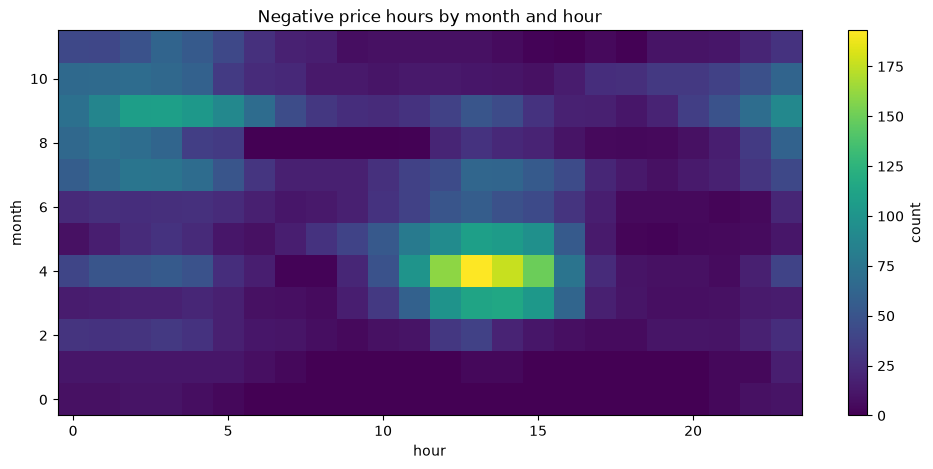

In [58]:
neg_grid = negatives.groupby(
    [negatives["time_start"].dt.month, negatives["time_start"].dt.hour]
).size().unstack(fill_value=0)

plt.figure(figsize=(12, 5))
plt.imshow(neg_grid, aspect="auto", origin="lower")
plt.colorbar(label="count")
plt.xlabel("hour")
plt.ylabel("month")
plt.title("Negative price hours by month and hour")
plt.show()

The strongest block is months 3-5 around hours 11-15. That is solar: strong sun in spring while heating demand is already low. There is a second band in month 9 around hours 01-05. That one is at night, so it cannot be solar. It is most likely wind during the hours when demand is lowest. May has the most negative hours (1,329). The zones are fairly similar, SE2 has the most at 2,459 and SE3 the fewest at 1,863, so this happens across the whole country and not in one zone.

The yearly counts are flat rather than growing: 2,634 in 2024 and 2,743 in 2025. 2026 has 1,101 so far but the year is not finished. Because the two patterns have different causes, the model will need different features to catch them.

---

### Spikes

In [59]:
prices = prices.sort_values(["zone", "time_start"])

prices["rolling_median"] = (
    prices.groupby("zone")["eur_per_kwh"]
    .transform(lambda s: s.rolling(24 * 7, min_periods=24).median())
)

prices["is_spike"] = prices["eur_per_kwh"] > 3 * prices["rolling_median"]

print(f"Spike rows: {prices['is_spike'].sum():,} ({prices['is_spike'].mean():.2%})")
print("\nBy zone:")
print(prices.groupby("zone")["is_spike"].mean())
print("\nBy month:")
print(prices.groupby(prices["time_start"].dt.month)["is_spike"].mean())

Spike rows: 22,287 (9.42%)

By zone:
zone
SE1    0.093139
SE2    0.107929
SE3    0.085786
SE4    0.089876
Name: is_spike, dtype: float64

By month:
time_start
1     0.055108
2     0.040292
3     0.080994
4     0.089633
5     0.093558
6     0.075248
7     0.065476
8     0.152890
9     0.113819
10    0.175000
11    0.129663
12    0.071429
Name: is_spike, dtype: float64


In [60]:
se3 = prices[prices["zone"] == "SE3"].reset_index(drop=True)
spike_idx = se3.index[se3["is_spike"]]

gaps = pd.Series(spike_idx).diff()
print(gaps.describe())
print(f"\nSpikes within 1 hour of another: {(gaps == 1).mean():.1%}")

count    5074.000000
mean       11.519117
std        99.863059
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max      4550.000000
dtype: float64

Spikes within 1 hour of another: 88.2%


Spikes come in groups, not as single hours. 88.2% of spikes are directly next to another spike, and the median gap between two spikes is 1 hour. The mean gap is 11.5 hours but the standard deviation is 99.9 and the largest gap is 4,550 hours, so the data has long quiet periods and then dense clusters. This means predicting "today will be a spiky day" is a much easier problem than predicting one exact spiky hour.

The threshold needs more thought. Using 3 times the rolling median flags 9.42% of all rows, which is too many for something called a spike. In SE1 the median price is 0.0217, so 3 times that is only 0.065, which is just a normal winter evening and not an unusual event. The monthly numbers show the same problem. October has the highest spike rate at 17.5%, but October is also the cheapest month of the year. A small number times three is still a small number.

---

### Cross-zone correlation

In [61]:
corr = pivot[["SE1", "SE2", "SE3", "SE4"]].corr()
print(corr)

zone       SE1       SE2       SE3       SE4
zone                                        
SE1   1.000000  0.991756  0.793440  0.639511
SE2   0.991756  1.000000  0.787543  0.633886
SE3   0.793440  0.787543  1.000000  0.913811
SE4   0.639511  0.633886  0.913811  1.000000


In [62]:
print(daily[["SE1", "SE2", "SE3", "SE4"]].corr())

zone       SE1       SE2       SE3       SE4
zone                                        
SE1   1.000000  0.996924  0.874282  0.777041
SE2   0.996924  1.000000  0.870431  0.773773
SE3   0.874282  0.870431  1.000000  0.942590
SE4   0.777041  0.773773  0.942590  1.000000


SE1 and SE2 are almost the same market: 0.992 hourly, 0.997 daily. SE3 and SE4 are also close at 0.914 and 0.943. But SE1 and SE4 only reach 0.640 hourly. The north and the south move quite independently. SE3 sits in the middle. It is closer to SE4 (0.914) than to SE1 (0.793), so it belongs with the south rather than the north. For the zone transfer experiment this means SE1 to SE2 should work almost perfectly, and SE1 to SE4 should be the hardest case.

---

### Weather vs price

In [63]:
prices_h = (
    prices.set_index("time_start")
    .groupby("zone")["eur_per_kwh"]
    .resample("h")
    .mean()
    .reset_index()
    .rename(columns={"time_start": "timestamp"})
)

merged = prices_h.merge(weather, on=["zone", "timestamp"], how="inner")
print(len(merged))
print(merged["timestamp"].min(), merged["timestamp"].max())

122404
2022-11-01 00:00:00+01:00 2026-06-01 08:00:00+02:00


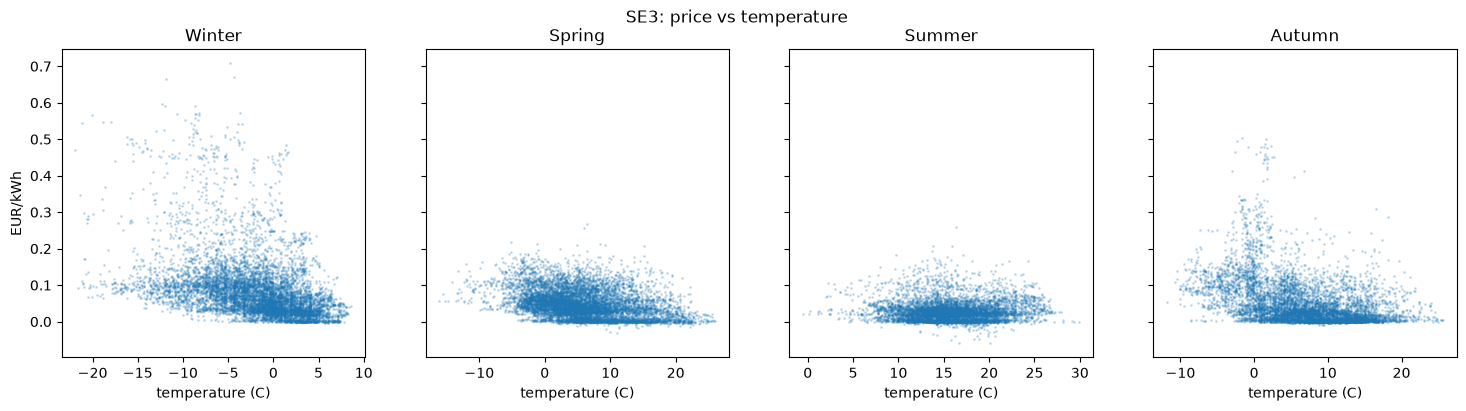

In [64]:
merged["month"] = merged["timestamp"].dt.month
merged["season"] = merged["month"] % 12 // 3
season_names = {0: "Winter", 1: "Spring", 2: "Summer", 3: "Autumn"}

se3 = merged[merged["zone"] == "SE3"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, (s, name) in zip(axes, season_names.items()):
    sub = se3[se3["season"] == s]
    ax.scatter(sub["temperature"], sub["eur_per_kwh"], s=1, alpha=0.2)
    ax.set_title(name)
    ax.set_xlabel("temperature (C)")
axes[0].set_ylabel("EUR/kWh")
plt.suptitle("SE3: price vs temperature")
plt.show()

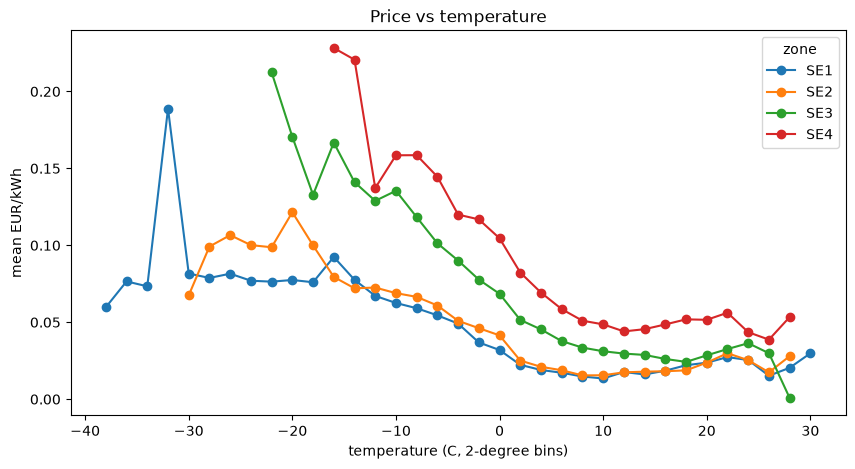

In [65]:
merged["temp_bin"] = (merged["temperature"] // 2) * 2

binned = merged.groupby(["zone", "temp_bin"])["eur_per_kwh"].mean().unstack(0)
binned.plot(figsize=(10, 5), marker="o")
plt.xlabel("temperature (C, 2-degree bins)")
plt.ylabel("mean EUR/kWh")
plt.title("Price vs temperature")
plt.show()

In [66]:
print(merged.groupby("zone")[["eur_per_kwh", "temperature", "wind_speed"]].corr().unstack()["eur_per_kwh"])

      eur_per_kwh  temperature  wind_speed
zone                                      
SE1           1.0    -0.391579   -0.249120
SE2           1.0    -0.379771   -0.127893
SE3           1.0    -0.448379   -0.216081
SE4           1.0    -0.356030   -0.282329


In [67]:
merged["is_negative"] = merged["eur_per_kwh"] < 0
print(merged.groupby("is_negative")["wind_speed"].mean())
print(merged.groupby("is_negative")["temperature"].mean())

is_negative
False    3.296021
True     4.927003
Name: wind_speed, dtype: float64
is_negative
False     4.741893
True     10.703500
Name: temperature, dtype: float64


Temperature works. Correlation is -0.36 to -0.45 in every zone, and price rises steadily as it gets colder. The curve gets steep below 0 C and flat above 10 C. The season plots show the effect only exists in winter and autumn. In summer temperature carries almost no information. Wind matters less: -0.13 to -0.28, strongest in SE4 which has the most wind power. Negative price hours confirm both causes: 4.93 m/s wind against 3.30 normally, and 10.7 C against 4.74 normally. Warm and windy at the same time.

---

### Regime changes

In [68]:
prices["is_quarter"] = prices["time_start"] >= "2025-10-01"

print(prices.groupby(["zone", "is_quarter"])["eur_per_kwh"].agg(["mean", "std", "min", "max"]))

                     mean       std      min      max
zone is_quarter                                      
SE1  False       0.034501  0.051371 -0.06004  0.59000
     True        0.039511  0.043108 -0.09459  0.41776
SE2  False       0.034378  0.051470 -0.06004  0.59000
     True        0.040017  0.043711 -0.01168  0.47197
SE3  False       0.051568  0.063770 -0.06004  0.70752
     True        0.066515  0.047392 -0.01449  0.51828
SE4  False       0.065048  0.067462 -0.06004  0.69909
     True        0.081226  0.057270 -0.01559  0.79748


In [69]:
oct_mar = prices[prices["month"].isin([10, 11, 12, 1, 2, 3])]

print(oct_mar.groupby(["zone", "is_quarter"])["eur_per_kwh"].agg(["mean", "std"]))

                     mean       std
zone is_quarter                    
SE1  False       0.048776  0.065919
     True        0.045557  0.049017
SE2  False       0.048268  0.066236
     True        0.044858  0.049719
SE3  False       0.072461  0.080357
     True        0.070778  0.049425
SE4  False       0.080345  0.082507
     True        0.081065  0.052243


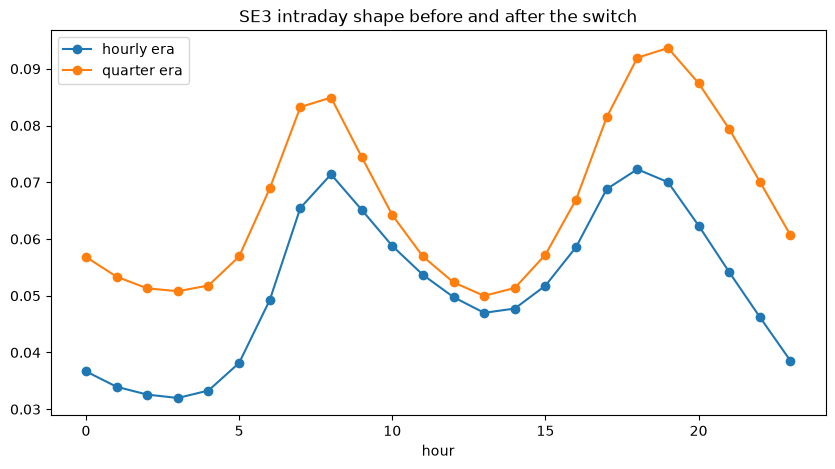

In [70]:
se3_all = prices[prices["zone"] == "SE3"]
shape = se3_all.groupby(["is_quarter", "hour"])["eur_per_kwh"].mean().unstack(0)
shape.columns = ["hourly era", "quarter era"]
shape.plot(figsize=(10, 5), marker="o")
plt.title("SE3 intraday shape before and after the switch")
plt.show()

Comparing all data looks like prices rose, but the period after the switch has more winter in it. Comparing only October to March, the means are nearly the same. The real change is volatility. SE3 std drops from 0.080 to 0.049, SE4 from 0.083
to 0.052. Part of this is probably just averaging quarter-hours into hours, not a real market change. The night price is also much higher after the switch (0.057 against 0.037 at hour 0) and the evening peak moved an hour later. Only 350 days after the switch, so this is not strong evidence yet.

---

### Gaps and thresholds

In [71]:
se4_w = weather[weather["zone"] == "SE4"].sort_values("timestamp")
gaps = se4_w["timestamp"].diff()
big = gaps[gaps > pd.Timedelta("1h")]
print(big.sort_values(ascending=False).head(10))
print(se4_w.loc[big.sort_values(ascending=False).head(5).index, "timestamp"])

115435   114 days 05:00:00
115295     2 days 00:00:00
98635      0 days 12:00:00
98638      0 days 12:00:00
98636      0 days 06:00:00
98637      0 days 06:00:00
95253      0 days 05:00:00
112871     0 days 05:00:00
116910     0 days 04:00:00
112226     0 days 04:00:00
Name: timestamp, dtype: timedelta64[us]
115435   2025-08-14 14:00:00+02:00
115295   2025-04-16 14:00:00+02:00
98635    2023-05-18 08:00:00+02:00
98638    2023-05-19 08:00:00+02:00
98636    2023-05-18 14:00:00+02:00
Name: timestamp, dtype: datetime64[us, Europe/Stockholm]


In [72]:
nulls = weather[weather["wind_speed"].isna()]
print(nulls.groupby("zone").size())
print(nulls.groupby(nulls["timestamp"].dt.to_period("M")).size().head(20))

zone
SE1     68
SE2    135
SE3     61
SE4     61
dtype: int64
timestamp
2022-11    56
2022-12     2
2023-01     7
2023-02    10
2023-03     9
2023-04     2
2023-05    12
2023-06     5
2023-07     3
2023-08    23
2023-09    17
2023-11     5
2023-12    43
2024-01     6
2024-02     1
2024-03     2
2024-04     3
2024-05     2
2024-06     3
2024-08     3
Freq: M, dtype: int64


/var/folders/9g/db8mvdwn41v2whx5smnq9k580000gn/T/ipykernel_49679/948908815.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  print(nulls.groupby(nulls["timestamp"].dt.to_period("M")).size().head(20))


In [73]:
for mult in [3, 5, 10]:
    flag = prices["eur_per_kwh"] > mult * prices["rolling_median"]
    print(f"{mult}x: {flag.sum():,} rows ({flag.mean():.2%})")

3x: 22,287 rows (9.42%)
5x: 11,549 rows (4.88%)
10x: 4,839 rows (2.04%)


The biggest SE4 weather gap is 114 days ending 2025-08-14, so roughly April to August 2025 is missing. The rest are 4 to 12 hours. Wind nulls are mostly SE2 (135), and 56 of all nulls are in November 2022. Spike threshold: 3x flags 9.42% of rows, 5x flags 4.88%, 10x flags 2.04%. 3x is too loose. 5x or 10x is more realistic.

---

- Hour and season interact. The evening peak moves from 17:00 in winter to 20:00 in summer
- Weekends are much cheaper. is_weekend plus day of week are both worth having
- Temperature is a useful feature, wind much less so. Temperature only matters in winter and autumn
- Spikes come in groups, so predicting a spiky day is more realistic than predicting a single spiky hour
- SE1 and SE2 are nearly the same market. SE3 belongs with the south. Zone transfer should work between SE1 and SE2 and fail between SE1 and SE4
- The SE4-SE1 spread is growing over time, which matters when training on early data and testing on later data
- The first two months are energy crisis prices and may need separate treatment

---